In [2]:
import os
import matplotlib.pyplot as plt

from collections import defaultdict
import time


class SortedDict:
    def __init__(self):
        self.data = defaultdict(list)

    def insert(self, key: int, value: tuple[int, int]):
        self.data[key].append(value)
        self.data[key].sort(key=lambda x: x[1])

    def get(self, key: int):
        return self.data.get(key, [])

    def display(self):
        for k, v in self.data.items():
            print(f"{k}: {v}")


def refine(file, sorted_dict): 
    lines = file.readlines()
    for line in lines:
        line = line.replace(" ", "").replace("\n", "").split(":")
        id = int(line[0])
        line = line[1].split(";")[:-1]
        for item in line:
            item = item.replace('(', '').replace(')', '').split(",")
            item[0] = int(item[0])
            item[1] = int(item[1])
            item = tuple(item)
            sorted_dict.insert(id, item)
        # exit(0)

def compare_lists(list1, list2):
        set1, set2 = set(list1), set(list2)

        only_in_list1 = set1 - set2
        only_in_list2 = set2 - set1
        common_elements = set1 & set2

        return {
            "only_in_list1": sorted(only_in_list1, key=lambda x: x[1]),
            "only_in_list2": sorted(only_in_list2, key=lambda x: x[1]),
            "common_elements": sorted(common_elements, key=lambda x: x[1]),
        }

def compute_ratios(differences):
        list1_sizes = []
        list2_sizes = []
        ratio_all = []
        ratio_only_in_list1 = []
        ratio_only_in_list2 = []
        ratio_common = []

        for key, diff in differences.items():
            size1 = len(diff['only_in_list1']) + len(diff['common_elements'])
            size2 = len(diff['only_in_list2']) + len(diff['common_elements'])

            if size1 > 0 and size2 > 0:
                ratio_all.append(size2 / size1)

            if len(diff['only_in_list1']) > 0 and size1 > 0:
                ratio_only_in_list1.append(len(diff['only_in_list1']) / size1)

            if len(diff['only_in_list2']) > 0 and size1 > 0:
                ratio_only_in_list2.append(len(diff['only_in_list2']) / size1)

            if len(diff['common_elements']) > 0 and size1 > 0:
                ratio_common.append(len(diff['common_elements']) / size1)

        return ratio_all, ratio_only_in_list1, ratio_only_in_list2, ratio_common

def plot_ratios(ratio_all, ratio_only_in_list1, ratio_only_in_list2, ratio_common):
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        axes[0, 0].hist(ratio_all, bins=100, alpha=0.7, color='b')
        axes[0, 0].set_title("Ratio of total elements in list2 vs list1")

        axes[0, 1].hist(ratio_only_in_list1, bins=100, alpha=0.7, color='r')
        axes[0, 1].set_title("Ratio of only_in_list1 elements vs list1")

        axes[1, 0].hist(ratio_only_in_list2, bins=100, alpha=0.7, color='g')
        axes[1, 0].set_title("Ratio of only_in_list2 elements vs list1")

        axes[1, 1].hist(ratio_common, bins=100, alpha=0.7, color='purple')
        axes[1, 1].set_title("Ratio of common elements vs list1")

        plt.tight_layout()
        plt.savefig("indexes/ratios.png")

In [2]:
file0 = open("indexes/neighbors0.txt", "r")
file1 = open("indexes/neighbors1.txt", "r")
file2 = open("indexes/neighbors2.txt", "r")
file3 = open("indexes/neighbors3.txt", "r")

sorted_dict0 = SortedDict()
sorted_dict1 = SortedDict()
sorted_dict2 = SortedDict()
sorted_dict3 = SortedDict()

refine(file0, sorted_dict0)
print("refined")
refine(file1, sorted_dict1)
print("refined")
refine(file2, sorted_dict2)
print("refined")
refine(file3, sorted_dict3)
print("refined")

refined
refined
refined
refined


In [19]:
import random
randomint = [random.randint(0, 1000000) for i in range(10)]
print(randomint)
for it in randomint:
    print(it)
    if it<500000:
      print(sorted_dict0.get(it))
      print(sorted_dict1.get(it))
      print(sorted_dict3.get(it))
    else:
      print(sorted_dict0.get(it))
      print(sorted_dict2.get(it))
      print(sorted_dict3.get(it))

[363244, 807253, 833337, 917218, 955018, 430062, 907193, 290900, 378008, 290639]
363244
[(362574, 3495), (350290, 24440), (207477, 40602), (235337, 41141), (828896, 44044), (660162, 50526), (327878, 53108), (394148, 56010), (323952, 56454)]
[(362574, 3495), (350290, 24440), (207477, 40602), (235337, 41141), (327878, 53108), (394148, 56010), (323952, 56454)]
[(362574, 3495), (350290, 24440), (207477, 40602), (235337, 41141), (755811, 52426), (327878, 53108), (394148, 56010), (323952, 56454)]
807253
[(2398, 69523), (343498, 69940), (440336, 70961), (20736, 77072), (311470, 79011), (4882, 81038), (576222, 81288), (897860, 84045), (460003, 88082), (970916, 126673)]
[(596586, 72803), (576222, 81288), (549739, 85232), (531457, 87837), (692850, 90304), (553344, 90320), (787182, 90699), (732157, 91392), (693853, 96373), (890550, 100763)]
[(596586, 72803), (576222, 81288), (549739, 85232), (531457, 87837), (692850, 90304), (553344, 90320), (787182, 90699), (732157, 91392), (173459, 92521), (693

In [6]:
def compare(dict1, dict2):
    f=open("indexes/diff.txt", "w")
    diff_results = {}
    for key in dict1.keys():
        value1, value2 = dict1.get(key), dict2.get(key)
        diff_results[key] = compare_lists(value1, value2)
        f.write(f"{key}: {diff_results[key]}\n")
    f.close()
    
compare(sorted_dict0.data, sorted_dict3.data)

Time taken to read diff file: 92.65639972686768


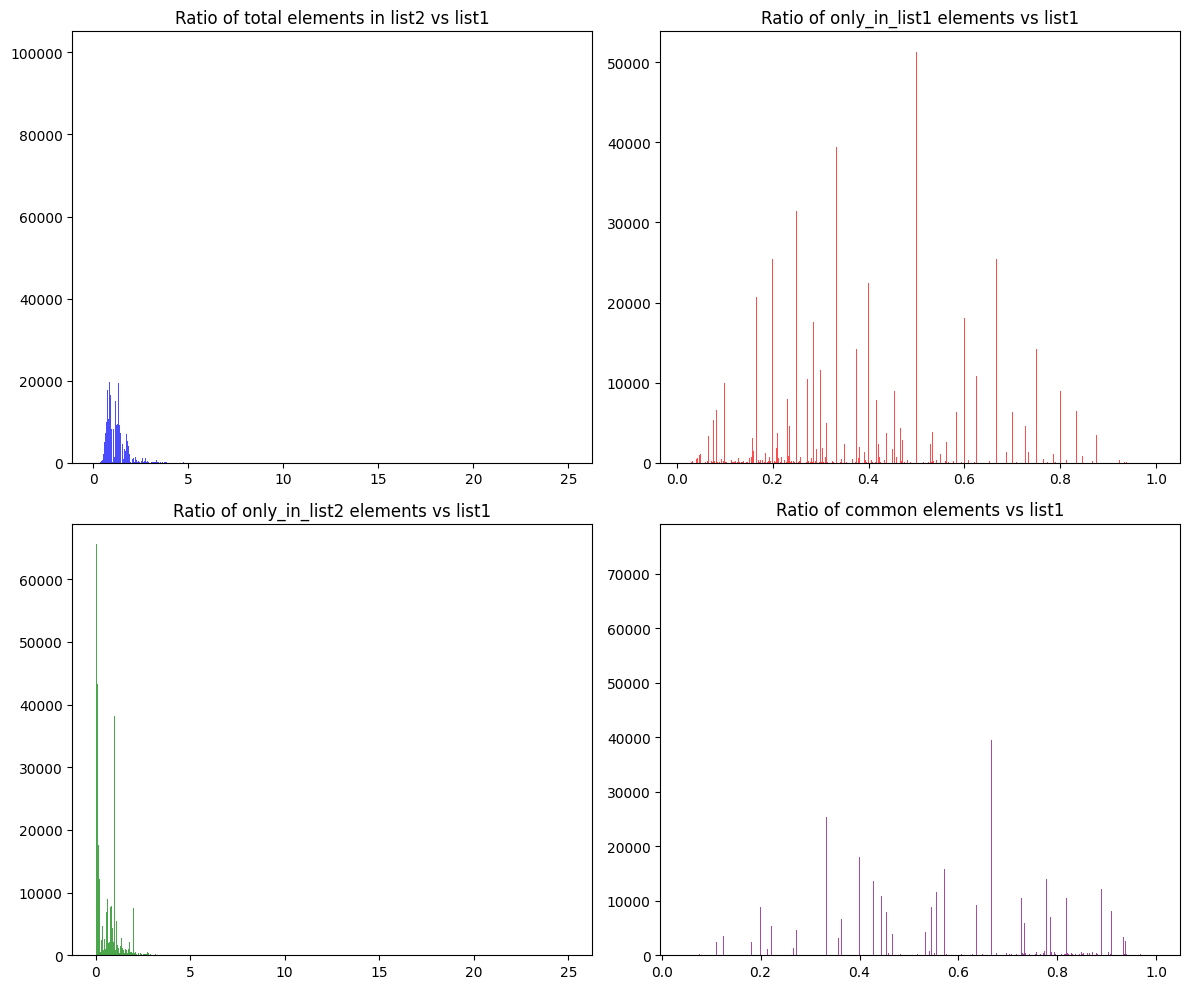

In [7]:
diff_results = {}
start = time.time()
with open("indexes/diff.txt", "r") as f:
    for line in f:
        key, value = line.split(":", 1)
        diff_results[int(key.strip())] = eval(value.strip())

end = time.time()
print(f"Time taken to read diff file: {end - start}")

ratios = compute_ratios(diff_results)
plot_ratios(*ratios)


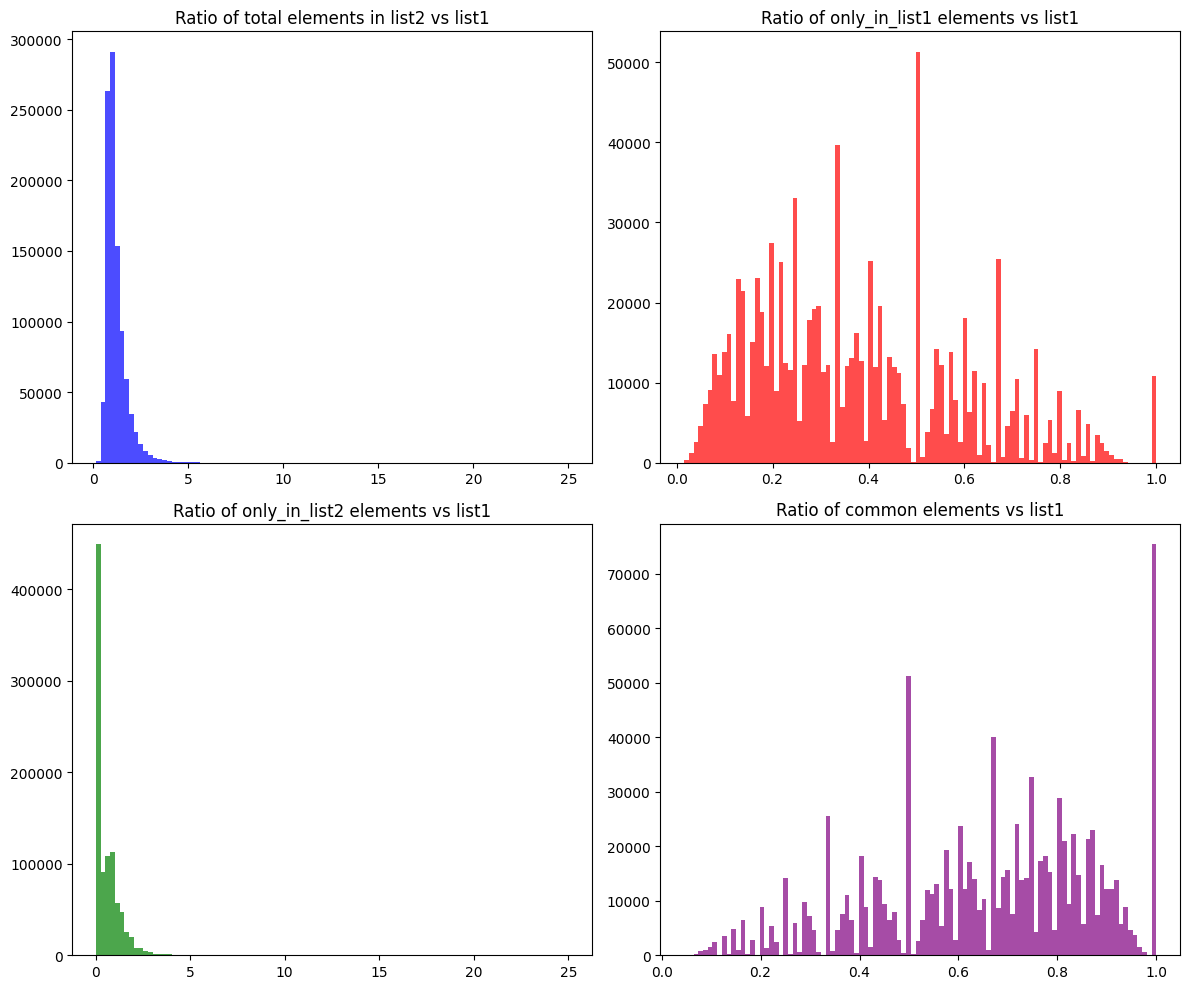

In [12]:
plot_ratios(*ratios)

In [13]:
total_size1, total_size2, count = 0, 0, 0

for key, diff in diff_results.items():
    size1 = len(diff["only_in_list1"]) + len(diff["common_elements"])
    size2 = len(diff["only_in_list2"]) + len(diff["common_elements"])
    
    total_size1 += size1
    total_size2 += size2
    count += 1

# 计算平均值
avg_size1 = total_size1 / count if count > 0 else 0
avg_size2 = total_size2 / count if count > 0 else 0

# 输出结果
avg_size1, avg_size2

(15.77263, 16.86964)

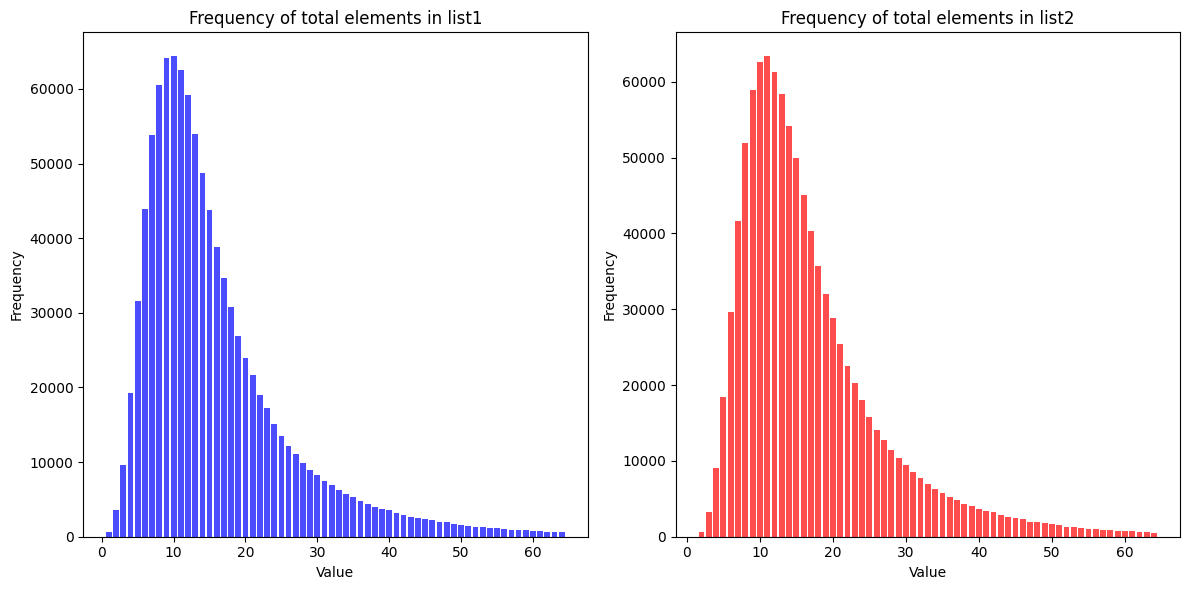

In [14]:
list1_sizes = []
list2_sizes = []
for key, diff in diff_results.items():
            size1 = len(diff['only_in_list1']) + len(diff['common_elements'])
            size2 = len(diff['only_in_list2']) + len(diff['common_elements'])
            list1_sizes.append(size1)
            list2_sizes.append(size2)
# fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# axes[0].hist(list1_sizes, bins=2000, alpha=0.7, color='b')
# axes[0].set_title("total elements in list1")

# axes[1].hist(list2_sizes, bins=2000, alpha=0.7, color='r')
# axes[1].set_title("total elements in list2")

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 计算数值出现的次数
count_list1 = Counter(list1_sizes)
count_list2 = Counter(list2_sizes)

# 提取 x 和 y 值
x1, y1 = zip(*sorted(count_list1.items()))
x2, y2 = zip(*sorted(count_list2.items()))

# 绘制图像
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].bar(x1, y1, color='b', alpha=0.7)
axes[0].set_title("Frequency of total elements in list1")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

axes[1].bar(x2, y2, color='r', alpha=0.7)
axes[1].set_title("Frequency of total elements in list2")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")




plt.tight_layout()
plt.savefig("indexes/ratios-2.png")

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 读取邻居数据
def load_neighbors(file_path):
    neighbors = {}
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) < 2:
                continue
            node_id = int(parts[0].strip())  # 读取 ID
            neighbors_list = []
            for neighbor in parts[1].split(";"):
                neighbor = neighbor.strip()
                if not neighbor:
                    continue
                idx, dist = neighbor.strip("()").split(",")
                neighbors_list.append((int(idx), float(dist)))
            neighbors[node_id] = neighbors_list
    return neighbors

# 载入文件数据
file0_neighbors = load_neighbors("indexes/neighbors0.txt")
file1_neighbors = load_neighbors("indexes/neighbors1.txt")
file2_neighbors = load_neighbors("indexes/neighbors2.txt")

In [16]:
# 计算 ratio 数据
def compute_ratios(base_neighbors, compare_neighbors):
    common_ratios = []
    unique_ratios = []
    distance_ratios = []

    for node_id, base_list in base_neighbors.items():
        if node_id not in compare_neighbors:
            continue

        compare_list = compare_neighbors[node_id]

        # 提取邻居索引
        base_indices = {idx for idx, _ in base_list}
        compare_indices = {idx for idx, _ in compare_list}

        # 计算共同邻居
        common_neighbors = base_indices & compare_indices
        unique_neighbors = compare_indices - base_indices

        if len(base_indices) > 0:
            common_ratios.append(len(common_neighbors) / len(base_indices))
            unique_ratios.append(len(unique_neighbors) / len(base_indices))

        # 计算距离变化
        base_distances = [dist for _, dist in base_list if dist > 0]
        compare_distances = [dist for _, dist in compare_list if dist > 0]
        # for idx, dist in base_distances.items():
        #     if dist == 0:
        #         print(f"Zero distance in base list: {node_id}, {idx}")

        # common_distances = [
        #     compare_distances[idx] / base_distances[idx]
        #     for idx in common_neighbors if idx in base_distances and idx in compare_distances and base_distances[idx] > 0
        # ]

        # if common_distances:
            # distance_ratios.append(np.mean(common_distances))
        distance_ratios.append(np.mean(base_distances) / np.mean(compare_distances))

    return common_ratios, unique_ratios, distance_ratios

# 计算 file1/file2 与 file0 的比率
common_ratios1, unique_ratios1, distance_ratios1 = compute_ratios(file0_neighbors, file1_neighbors)
common_ratios2, unique_ratios2, distance_ratios2 = compute_ratios(file0_neighbors, file2_neighbors)


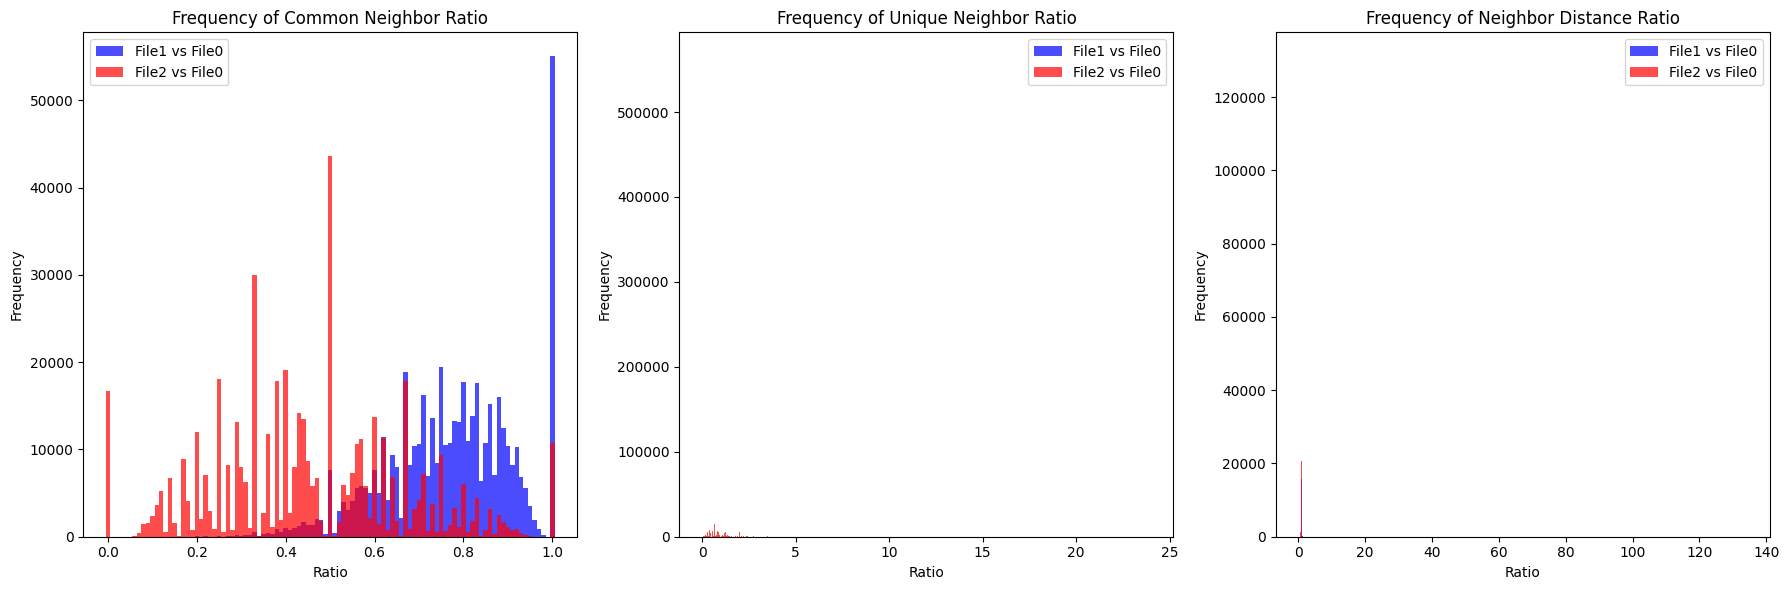

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


count_common_ratios1 = np.round(np.array(common_ratios1), 2)
count_common_ratios2 = np.round(np.array(common_ratios2), 2)
count_unique_ratios1 = np.round(np.array(unique_ratios1), 2)
count_unique_ratios2 = np.round(np.array(unique_ratios2), 2)
count_distance_ratios1 = np.round(np.array(distance_ratios1), 2)
count_distance_ratios2 = np.round(np.array(distance_ratios2), 2)

count_common_ratios1 = Counter(count_common_ratios1)
count_common_ratios2 = Counter(count_common_ratios2)
count_unique_ratios1 = Counter(count_unique_ratios1)
count_unique_ratios2 = Counter(count_unique_ratios2)
count_distance_ratios1 = Counter(count_distance_ratios1)
count_distance_ratios2 = Counter(count_distance_ratios2)

x_common1, y_common1 = zip(*sorted(count_common_ratios1.items()))
x_common2, y_common2 = zip(*sorted(count_common_ratios2.items()))

x_unique1, y_unique1 = zip(*sorted(count_unique_ratios1.items()))
x_unique2, y_unique2 = zip(*sorted(count_unique_ratios2.items()))

x_distance1, y_distance1 = zip(*sorted(count_distance_ratios1.items()))
x_distance2, y_distance2 = zip(*sorted(count_distance_ratios2.items()))


fig, axes = plt.subplots(1, 3, figsize=(18, 6))


axes[0].bar(x_common1, y_common1, color='b', alpha=0.7, width=0.01, label="File1 vs File0")
axes[0].bar(x_common2, y_common2, color='r', alpha=0.7, width=0.01, label="File2 vs File0")
axes[0].set_title("Frequency of Common Neighbor Ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# 唯一邻居比率分布（调整 y 轴缩放，使得柱子更明显）
axes[1].bar(x_unique1, y_unique1, color='b', alpha=0.7, width=0.01, label="File1 vs File0")
axes[1].bar(x_unique2, y_unique2, color='r', alpha=0.7, width=0.01, label="File2 vs File0")
axes[1].set_title("Frequency of Unique Neighbor Ratio")
axes[1].set_xlabel("Ratio")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].set_ylim(0, max(y_unique1 + y_unique2) * 1.2)  # 增强可见性


# 邻居距离变化比率分布（调整 y 轴缩放，使得柱子更明显）
axes[2].bar(x_distance1, y_distance1, color='b', alpha=0.7, width=0.01, label="File1 vs File0")
axes[2].bar(x_distance2, y_distance2, color='r', alpha=0.7, width=0.01, label="File2 vs File0")
axes[2].set_title("Frequency of Neighbor Distance Ratio")
axes[2].set_xlabel("Ratio")
axes[2].set_ylabel("Frequency")
axes[2].legend()
axes[2].set_ylim(0, max(y_distance1 + y_distance2) * 1.2)  # 增强可见性

plt.tight_layout()
plt.show()


In [31]:
print(y_unique1)
print(y_unique2)

(494834, 1, 1, 2, 1, 2, 1, 2, 5, 4, 5, 7, 6, 4, 6, 6, 13, 12, 10, 10, 10, 7, 9, 11, 11, 11, 22, 14, 21, 20, 17, 22, 15, 19, 19, 20, 28, 30, 41, 23, 27, 34, 27, 25, 32, 29, 35, 41, 36, 32, 32, 36, 33, 33, 51, 53, 33, 59, 34, 43, 36, 39, 52, 58, 39, 49, 43, 45, 40, 47, 27, 66, 45, 51, 56, 43, 37, 42, 37, 41, 36, 52, 28, 57, 46, 34, 51, 54, 17, 69, 33, 3, 112, 7, 144, 4, 135, 7, 11, 70, 39, 20, 47, 43, 31, 45, 32, 43, 25, 34, 33, 33, 38, 31, 55, 17, 33, 34, 24, 26, 25, 30, 41, 27, 26, 33, 35, 17, 18, 22, 32, 34, 14, 16, 28, 23, 17, 31, 14, 24, 1, 32, 41, 31, 1, 28, 5, 18, 10, 28, 18, 15, 14, 24, 9, 25, 17, 22, 16, 6, 15, 16, 8, 13, 11, 8, 9, 15, 7, 7, 10, 3, 12, 26, 1, 12, 12, 8, 1, 11, 18, 11, 30, 18, 32, 5, 22, 6, 10, 1, 1, 8, 15, 3, 1, 2, 2, 9, 2, 1, 3, 2, 4, 3, 1, 6, 6, 5, 5, 5, 3, 1, 3, 1, 6, 3, 1, 7, 3, 4, 5, 2, 4, 4, 2, 1, 1, 3, 6, 1, 1, 7, 1, 1, 3, 5, 8, 1, 3, 4, 1, 1, 3, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
(10491, 1, 15, 85, 333, 584, 1280, 1051, 1424, 1944, 2626, 396, 3

In [1]:
import numpy as np

def read_fvecs_manual(filename):
    """Reads .fvecs file manually, handling byte alignment."""
    with open(filename, 'rb') as f:
        vectors = []
        while True:
            # 先读取前 4 字节（int32 维度信息）
            dim_bytes = f.read(4)
            if not dim_bytes:
                break  # 文件读取完毕
            dim = np.frombuffer(dim_bytes, dtype=np.int32)[0]
            
            # 读取 dim 个 float32 数据
            vec_bytes = f.read(4 * dim)
            if len(vec_bytes) != 4 * dim:
                raise ValueError("Unexpected end of file or corrupted data.")
            
            vec = np.frombuffer(vec_bytes, dtype=np.float32)
            vectors.append(vec)
        
        return np.vstack(vectors)  # 合并成 NumPy 数组

# 读取数据
filename = "/ssd_root/dataset/sift1m/sift_base.fvecs"
vectors = read_fvecs_manual(filename)

print(f"Loaded {vectors.shape[0]} vectors with dimension {vectors.shape[1]}")
print(vectors[199787])  
print(vectors[264065])  
print(vectors[0])


Loaded 1000000 vectors with dimension 128
[ 88.  34.   0.   0.   0.   3.   7.  14.  75.  65.   5.  16.  17.  27.
   1.   3.  30.  27.   2.  11.   8.  42.  12.   3.  34.  53.   0.   0.
   0.  17.  22.   3. 124.  18.   0.   0.   0.   1.   1.  38. 124.  11.
  34.  53.   8.   1.   2.  73.  34.  22. 106.  92.  36.  29.  15.  12.
  14.  12.   4.   8.  42. 124.  68.   5.  65.  47.  36.  10.   6.   1.
   6.  30.  72.   3.   5.   8.   9.   7.  88. 124.   4.   0.  14.  10.
  51. 124. 124.  56.   0.   0.   0.   3.  72. 124.  35.   0.   1.  13.
  21.  20.  19.  11.  86.  11.   0.   1.   9.  35.  39.  18.  92.  70.
   4.   0.   1.   5.  18.  55. 109.  58.   1.   0.   4.  23.  33.  28.
  12.   9.]
[ 88.  34.   0.   0.   0.   3.   7.  14.  75.  65.   5.  16.  17.  27.
   1.   3.  30.  27.   2.  11.   8.  42.  12.   3.  34.  53.   0.   0.
   0.  17.  22.   3. 124.  18.   0.   0.   0.   1.   1.  38. 124.  11.
  34.  53.   8.   1.   2.  73.  34.  22. 106.  92.  36.  29.  15.  12.
  14.  12.   4.   8.  4

In [34]:
def read_stat(filename):
  counts = []
  means = []
  variances = []

  with open(filename, "r") as file:
      for line in file:
          count, mean, variance = int(line.strip().split(",")[0]), line.strip().split(",")[1], line.strip().split(",")[2]
          counts.append(count)
          means.append(mean)
          variances.append(variance)
          
  return counts, means, variances

In [35]:
count0, mean0, variance0 = read_stat("indexes/edgeLengthVariance0.txt")
count3, mean3, variance3 = read_stat("indexes/edgeLengthVariance3.txt")

In [15]:
import matplotlib.pyplot as plt

def plot_scatter(data, title, figsize=(12, 10), point_size=10):
    def refine_data(data):
        new_data = []
        for value in data:
            new_data.append(value if value < 5e9 else 0)
        return new_data
    data = refine_data(data)
    plt.figure(figsize=figsize)
    plt.scatter(range(len(data)), data, s=point_size)
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()
    

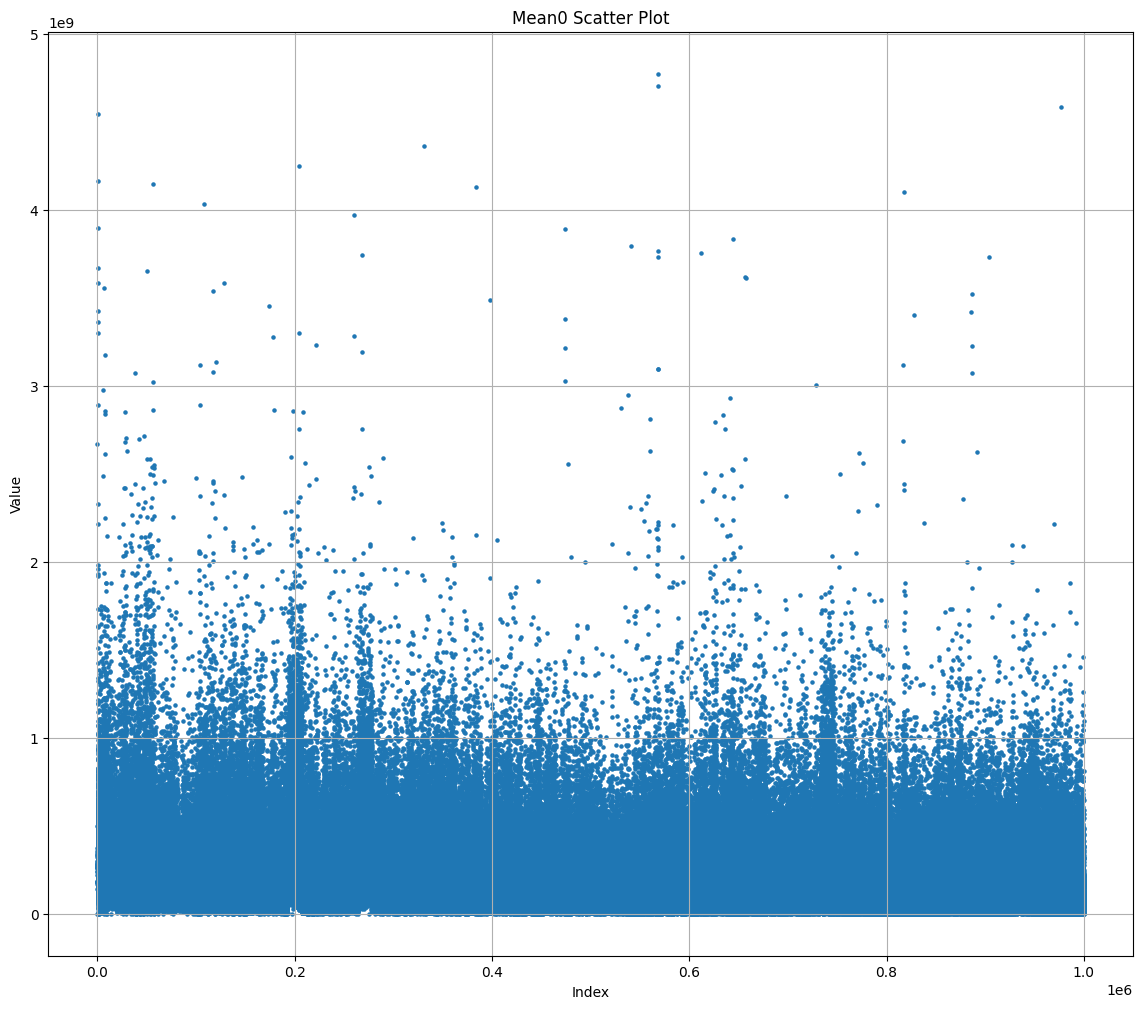

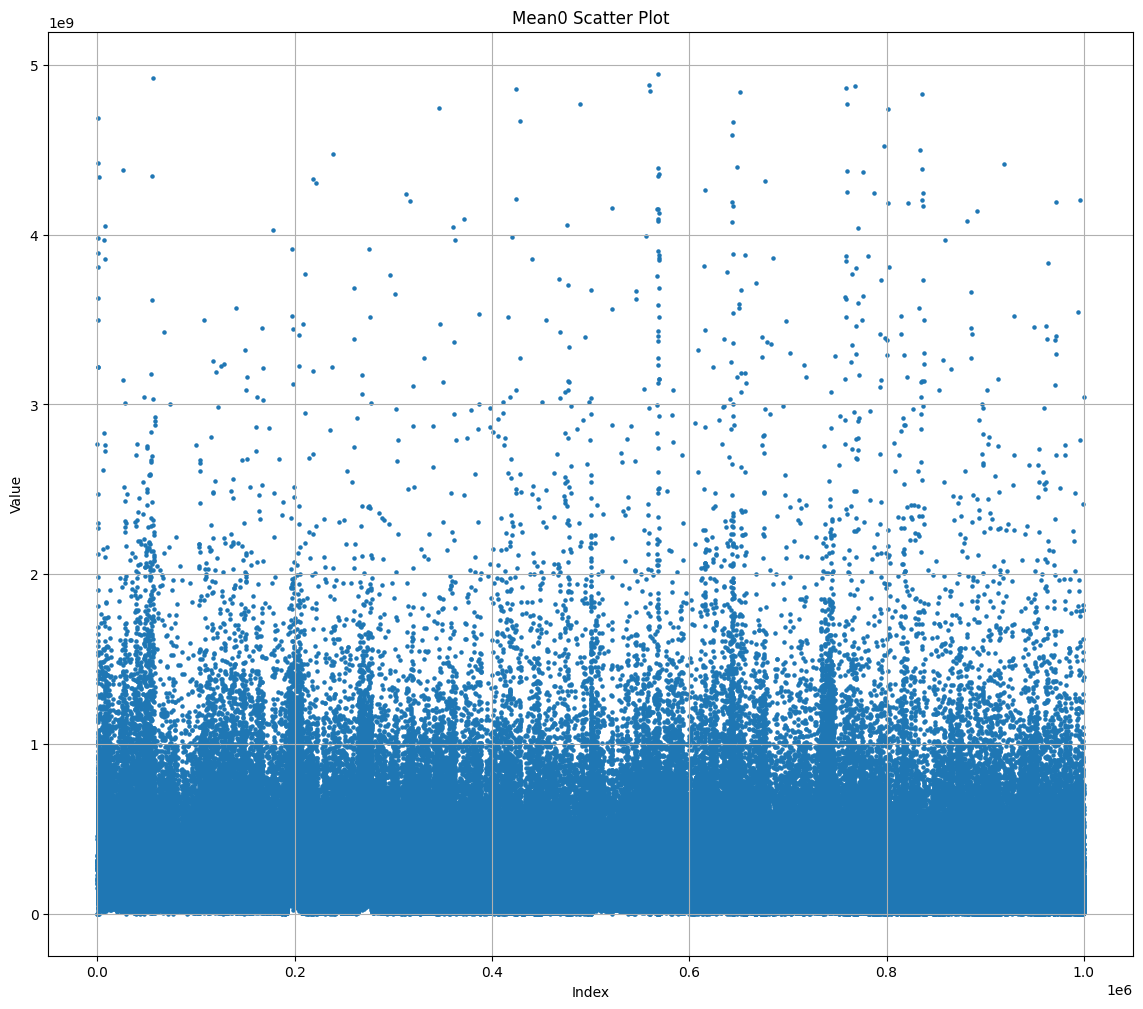

In [16]:
plot_scatter(variance0, "Mean0 Scatter Plot", figsize=(14, 12), point_size=5)
plot_scatter(variance3, "Mean0 Scatter Plot", figsize=(14, 12), point_size=5)


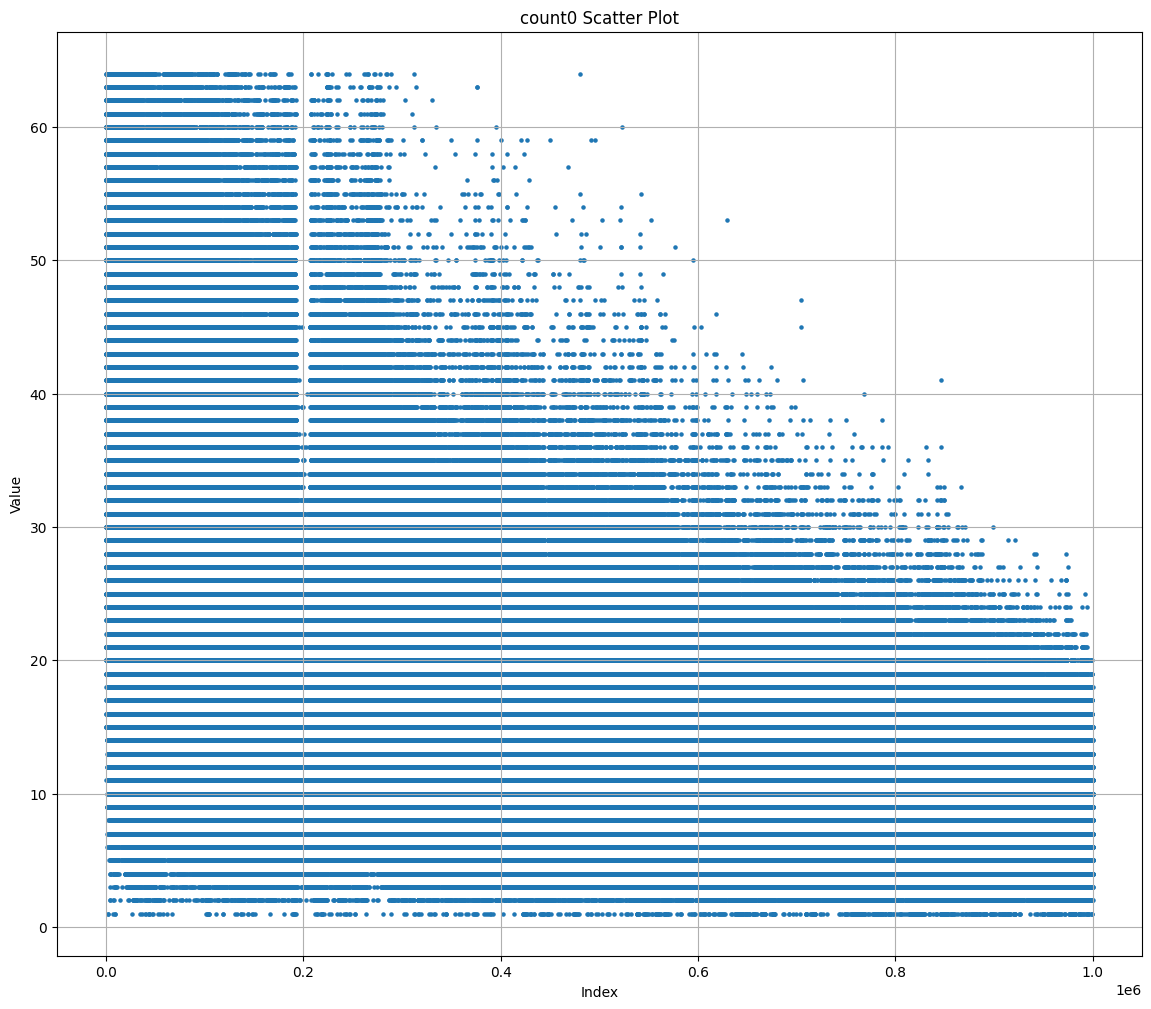

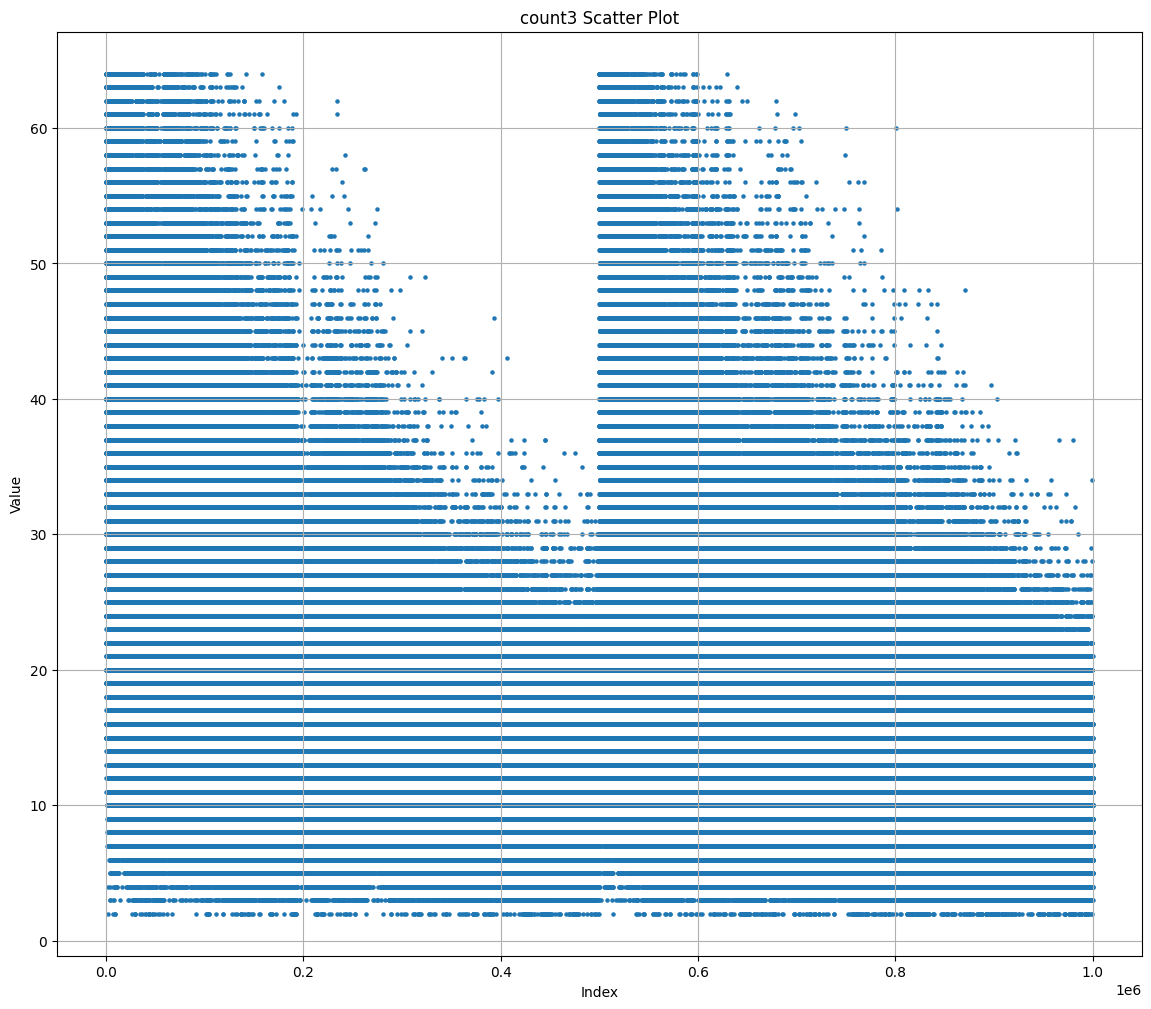

In [36]:
plot_scatter(count0, "count0 Scatter Plot", figsize=(14, 12), point_size=5)
plot_scatter(count3, "count3 Scatter Plot", figsize=(14, 12), point_size=5)

In [26]:
def plot_with_fit_return_function(data, title, figsize=(12, 10), point_size=10, degree=1):
    def refine_data(data):
        new_data = []
        for value in data:
            new_data.append(value if value < 2e9 else 0)
        return new_data
    data = refine_data(data)
    
    x = np.arange(len(data))
    y = np.array(data)
    
    # Fit the data with a polynomial of specified degree
    coefficients = np.polyfit(x, y, degree)
    fit_function = np.poly1d(coefficients)
    y_fit = fit_function(x)
    
    # Plot the scatter plot and the fitted curve
    plt.figure(figsize=figsize)
    plt.scatter(x, y, s=point_size, label='Data Points')
    plt.plot(x, y_fit, color='red', label=f'Polynomial Fit (degree={degree})')
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return fit_function

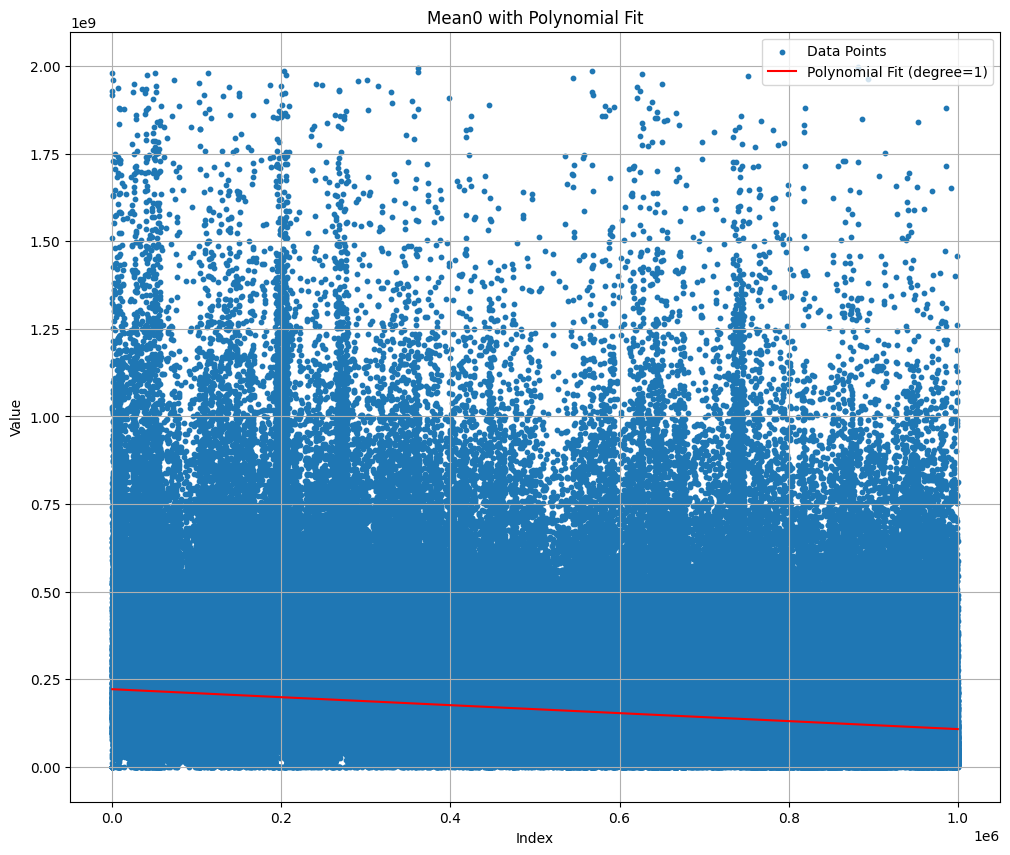

Fitted Function:  
-113.8 x + 2.213e+08


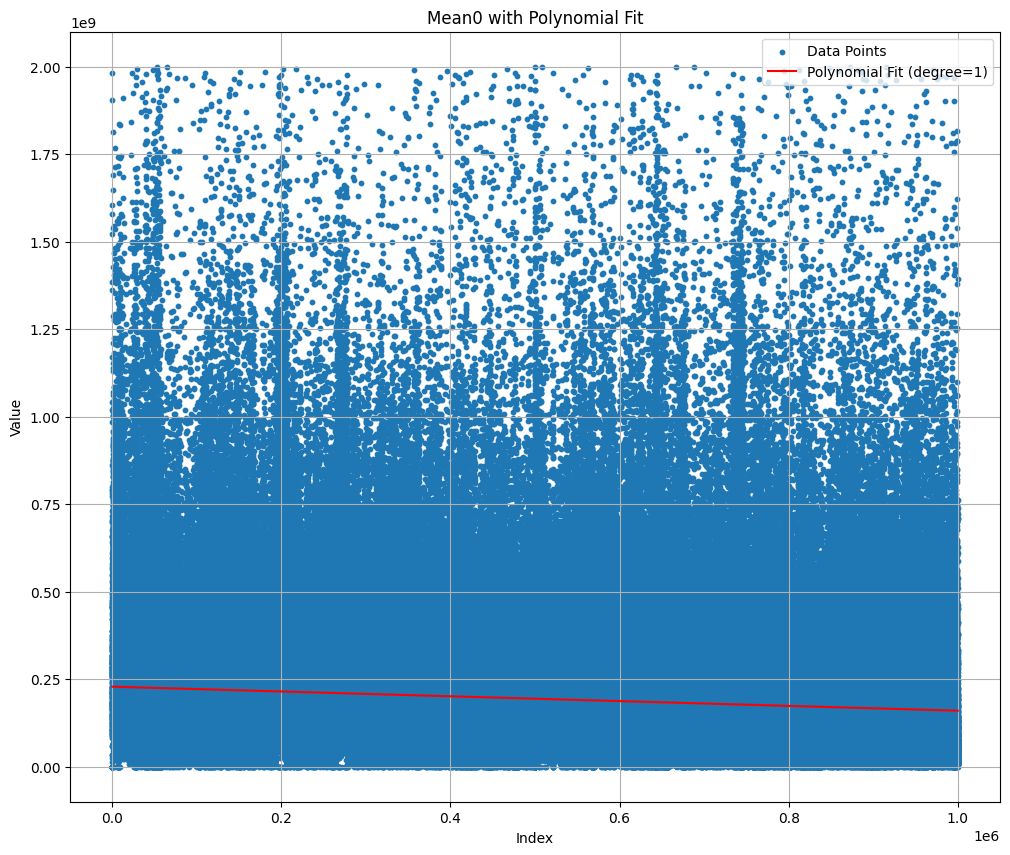

Fitted Function:  
-68.58 x + 2.286e+08


In [27]:
fitted_function = plot_with_fit_return_function(variance0, "variance0 with Polynomial Fit", degree=1)
print("Fitted Function:", fitted_function)

fitted_function = plot_with_fit_return_function(variance3, "variance3 with Polynomial Fit", degree=1)
print("Fitted Function:", fitted_function)

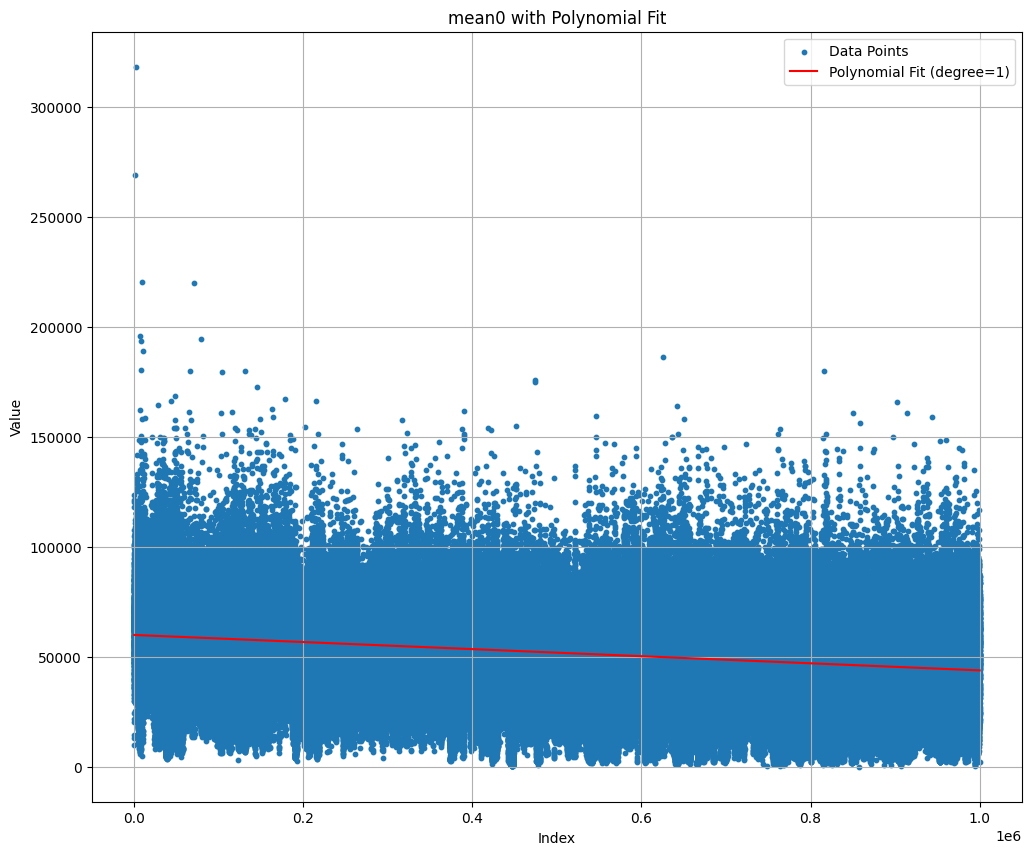

Fitted Function:  
-0.0161 x + 6.013e+04


/home/jin467/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


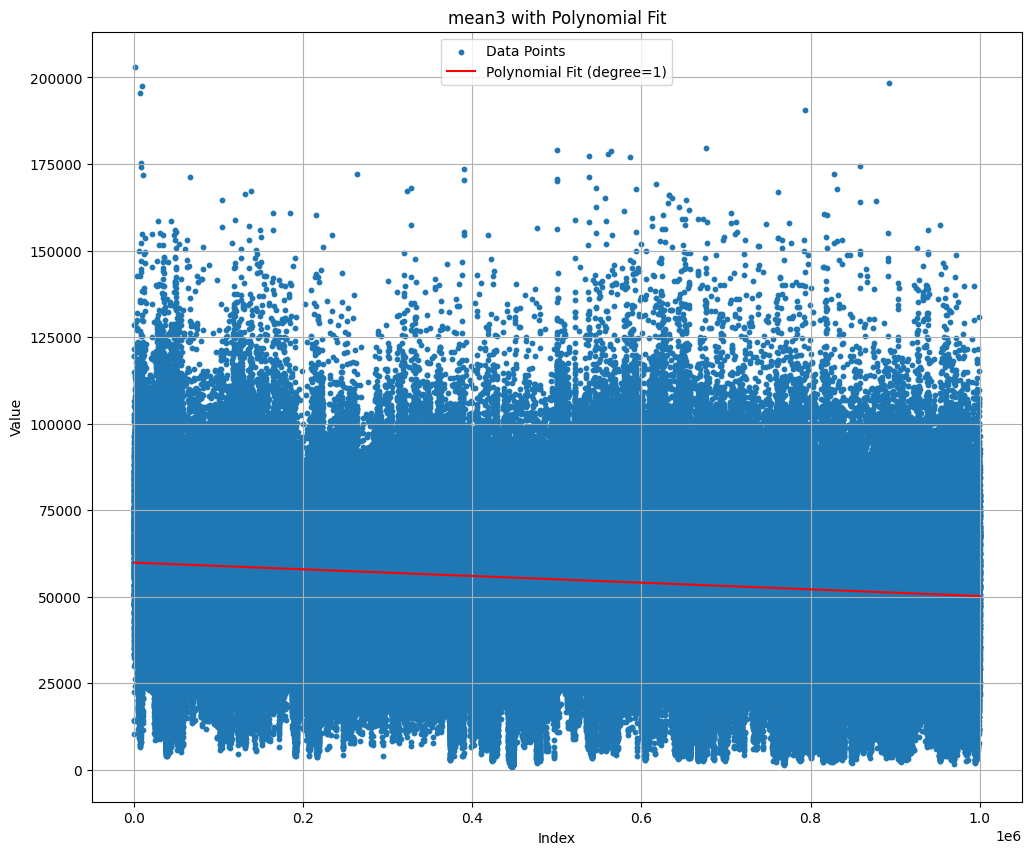

Fitted Function:  
-0.009643 x + 5.985e+04


In [28]:
fitted_function = plot_with_fit_return_function(mean0, "mean0 with Polynomial Fit", degree=1)
print("Fitted Function:", fitted_function)

fitted_function = plot_with_fit_return_function(mean3, "mean3 with Polynomial Fit", degree=1)
print("Fitted Function:", fitted_function)

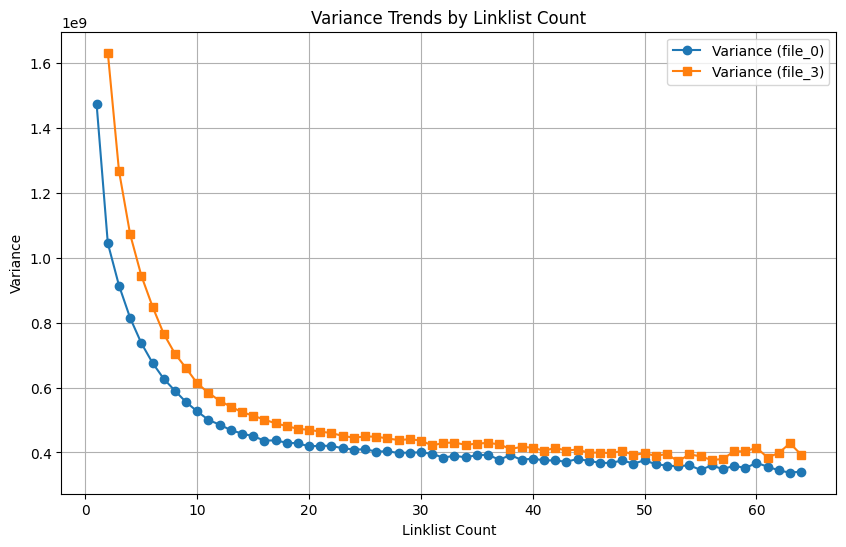

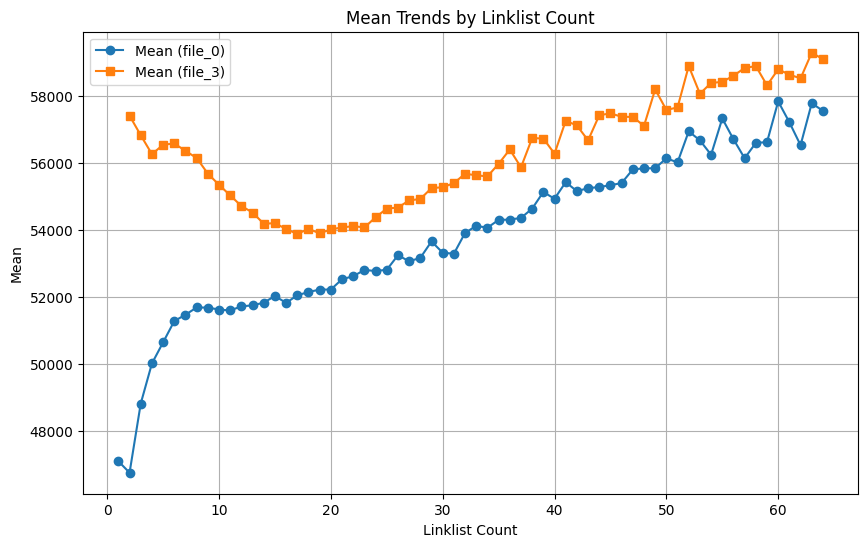

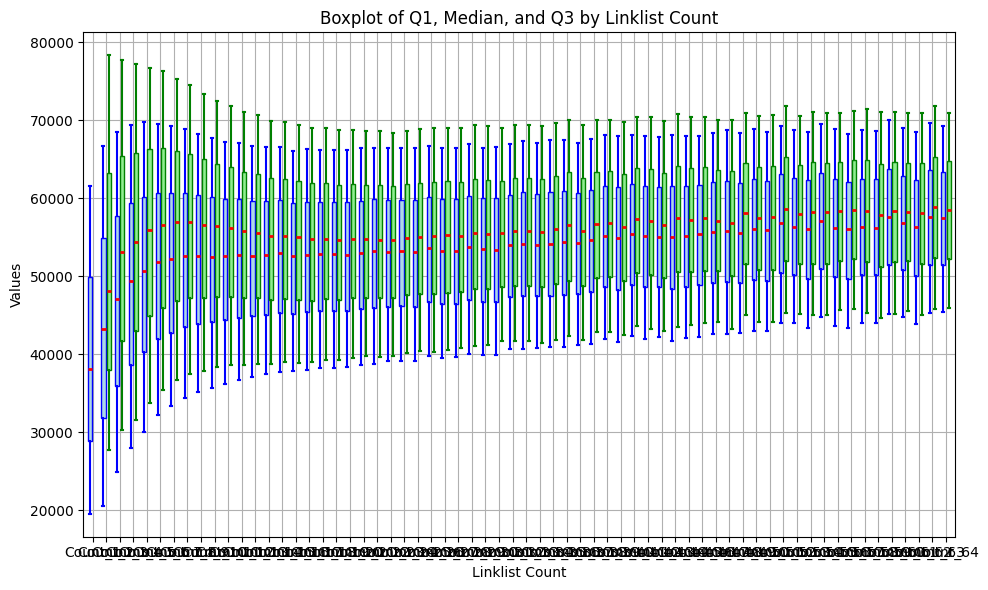

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 文件路径
file_0 = "indexes/statByLinklistCount0.txt"
file_3 = "indexes/statByLinklistCount3.txt"

# 读取文件内容
def read_file(filename):
    # 假设文件格式为：linklistCount, mean, variance, median, q1, q3
    columns = ["linklistCount", "mean", "variance", "median", "q1", "q3"]
    data = pd.read_csv(filename, header=None, names=columns)
    return data

# 加载两个文件的数据
data_0 = read_file(file_0)
data_3 = read_file(file_3)

# 图1: 方差 (Variance) 变化趋势
plt.figure(figsize=(10, 6))
plt.plot(data_0["linklistCount"], data_0["variance"], label="Variance (file_0)", marker="o")
plt.plot(data_3["linklistCount"], data_3["variance"], label="Variance (file_3)", marker="s")
plt.title("Variance Trends by Linklist Count")
plt.xlabel("Linklist Count")
plt.ylabel("Variance")
plt.legend()
plt.grid(True)
plt.show()

# 图2: 平均数 (Mean) 变化趋势
plt.figure(figsize=(10, 6))
plt.plot(data_0["linklistCount"], data_0["mean"], label="Mean (file_0)", marker="o")
plt.plot(data_3["linklistCount"], data_3["mean"], label="Mean (file_3)", marker="s")
plt.title("Mean Trends by Linklist Count")
plt.xlabel("Linklist Count")
plt.ylabel("Mean")
plt.legend()
plt.grid(True)
plt.show()

# 图3: 盒须图 (Median, Q1, Q3)
# 准备每个 linklistCount 的盒须图数据
unique_linklistCounts = sorted(set(data_0["linklistCount"]).union(data_3["linklistCount"]))

plt.figure(figsize=(10, 6))

positions = []  # 存储每个盒子的 x 轴位置
labels = []     # 存储每个盒子的标签

for i, count in enumerate(unique_linklistCounts):
    # 获取当前 linklistCount 的数据
    data_0_subset = data_0[data_0["linklistCount"] == count]
    data_3_subset = data_3[data_3["linklistCount"] == count]

    # 在同一 x 轴位置为 file_0 和 file_3 画出盒子
    if not data_0_subset.empty:
        box_0 = [data_0_subset["q1"].values[0], data_0_subset["median"].values[0], data_0_subset["q3"].values[0]]
        plt.boxplot(
            [[box_0[0], box_0[1], box_0[2]]],
            positions=[i - 0.2],  # 偏移到左侧
            widths=0.3,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="blue", linewidth=1.5),
            capprops=dict(color="blue", linewidth=1.5)
        )
        positions.append(i - 0.2)
        labels.append(f"file_0_{count}")

    if not data_3_subset.empty:
        box_3 = [data_3_subset["q1"].values[0], data_3_subset["median"].values[0], data_3_subset["q3"].values[0]]
        plt.boxplot(
            [[box_3[0], box_3[1], box_3[2]]],
            positions=[i + 0.2],  # 偏移到右侧
            widths=0.3,
            patch_artist=True,
            boxprops=dict(facecolor="lightgreen", color="green"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="green", linewidth=1.5),
            capprops=dict(color="green", linewidth=1.5)
        )
        positions.append(i + 0.2)
        labels.append(f"file_3_{count}")

# 设置 x 轴
plt.xticks(range(len(unique_linklistCounts)), [f"Count_{x}" for x in unique_linklistCounts])
plt.title("Boxplot of Q1, Median, and Q3 by Linklist Count")
plt.ylabel("Values")
plt.xlabel("Linklist Count")
plt.grid(True)
plt.tight_layout()

plt.show()


In [3]:
file0 = open("indexes/neighbors0.txt", "r")
# file1 = open("indexes/neighbors1.txt", "r")
# file2 = open("indexes/neighbors2.txt", "r")
file3 = open("indexes/neighbors3.txt", "r")

sorted_dict0 = SortedDict()
# sorted_dict1 = SortedDict()
# sorted_dict2 = SortedDict()
sorted_dict3 = SortedDict()

refine(file0, sorted_dict0)
print("refined")
# refine(file1, sorted_dict1)
# print("refined")
# refine(file2, sorted_dict2)
# print("refined")
refine(file3, sorted_dict3)
print("refined")

refined
refined


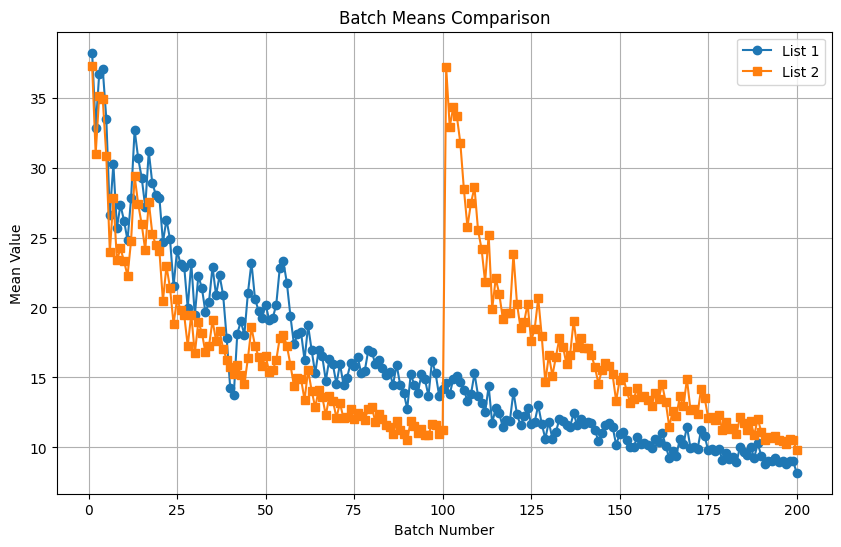

In [6]:
linklistsize0 = [len(item) for item in sorted_dict0.data.values()]
linklistsize3 = [len(item) for item in sorted_dict3.data.values()]

batch_size = 5000

# 函数：对每个批次求平均值
def calculate_batch_means(data, batch_size):
    return [sum(data[i:i+batch_size]) / batch_size for i in range(0, len(data), batch_size)]

# 计算两个列表的批次平均值
list1_means = calculate_batch_means(linklistsize0, batch_size)
list2_means = calculate_batch_means(linklistsize3, batch_size)

# 创建 x 轴（对应每个 batch 的编号）
x = range(1, len(list1_means) + 1)

# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(x, list1_means, label="List 1", marker="o")
plt.plot(x, list2_means, label="List 2", marker="s")

# 添加图例和标签
plt.title("Batch Means Comparison")
plt.xlabel("Batch Number")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True)

In [5]:
def calculate_average(self):
        result = []
        for key, values in self.data.items():
            less_than_500000 = [v[1] for v in values if v[0] < 500000]
            greater_equal_500000 = [v[1] for v in values if v[0] >= 500000]

            avg_less = sum(less_than_500000) / len(less_than_500000) if less_than_500000 else 0
            avg_greater_equal = sum(greater_equal_500000) / len(greater_equal_500000) if greater_equal_500000 else 0

            result.append([avg_less, avg_greater_equal])

        return result

In [6]:
dist_index0 = calculate_average(sorted_dict0)
dist_index3 = calculate_average(sorted_dict3)

In [12]:
import numpy as np

dist_index0 = np.array(dist_index0)
dist_index3 = np.array(dist_index3)

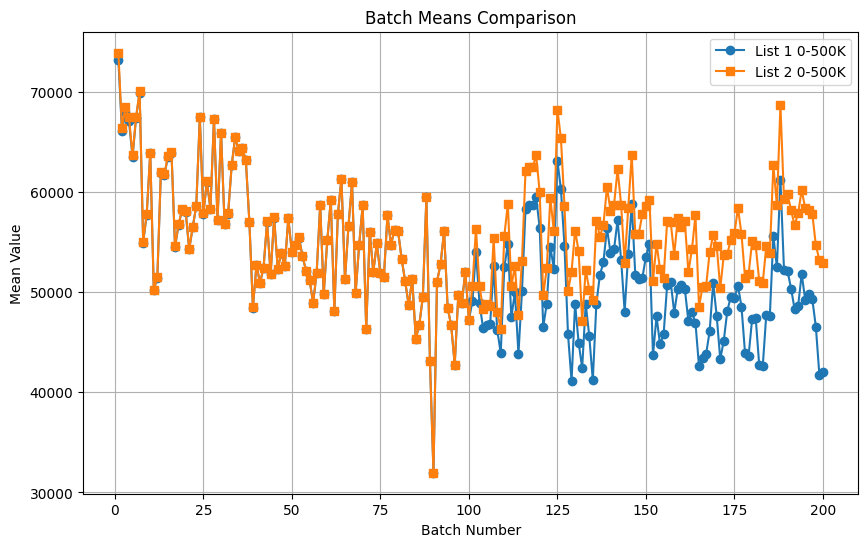

In [20]:
dist_index0_500k = dist_index0[:, 0]
dist_index3_500k = dist_index3[:, 0]
dist_index0_1m = dist_index0[:, 1]
dist_index3_1m = dist_index3[:, 1]

batch_size = 5000

# 函数：对每个批次求平均值
def calculate_batch_means(data, batch_size):
    return [sum(data[i:i+batch_size]) / batch_size for i in range(0, len(data), batch_size)]

# 计算两个列表的批次平均值
list1_means_500k = calculate_batch_means(dist_index0_500k, batch_size)
list2_means_500k = calculate_batch_means(dist_index3_500k, batch_size)
list1_means_1m = calculate_batch_means(dist_index0_1m, batch_size)
list2_means_1m = calculate_batch_means(dist_index3_1m, batch_size)

# 创建 x 轴（对应每个 batch 的编号）
x = range(1, len(list1_means_500k) + 1)

# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(x, list1_means_500k, label="List 1 0-500K", marker="o")
plt.plot(x, list2_means_500k, label="List 2 0-500K", marker="s")
# plt.plot(x, list1_means_1m, label="List 1 500K-1M", marker="o")
# plt.plot(x, list2_means_1m, label="List 2 500K-1M", marker="s")

# 添加图例和标签
plt.title("Batch Means Comparison")
plt.xlabel("Batch Number")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True)

In [5]:
input = "0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6519, 0, 0, 0, 0, 699, 22, 0, 501, 0, 0, 0, 0, 0, 0, 0, 909, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 172, 0, 1662, 0, 0, 0, 0, 845, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 850, 0, 2805, 0, 0, 0, 0, 0, 0, 0, 0, 82, 0, 0, 0, 0, 0, 0, 102907, 0, 0, 0, 0, 0, 0, 0, 103, 182, 0, 259, 21203, 0, 0, 2113, 0, 0, 0, 0, 17, 691, 0, 6, 0, 0, 0, 0, 318, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 80, 0, 0, 44, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 76, 1057, 9, 0, 0, 63, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 145, 0, 0, 0, 0, 0, 2, 8, 0, 468, 0, 0, 0, 1, 38, 0, 0, 0, 0, 0, 0, 0, 39, 0, 583, 0, 0, 0, 1733, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 116395, 0, 0, 0, 0, 0, 224, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 590, 0, 0, 0, 0, 76, 0, 0, 48686, 0, 0, 0, 4784, 14532, 26, 0, 97, 154, 0, 0, 0, 0, 0, 15165, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3122, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2012, 25, 0, 0, 0, 0, 0, 0, 0, 15120, 0, 0, 0, 0, 760, 0, 0, 0, 0, 0, 141, 0, 1, 109, 0, 0, 0, 0, 4589, 0, 0, 0, 0, 0, 0, 0, 0, 0, 282, 22, 293, 0, 0, 0, 0, 145347, 0, 0, 0, 0, 3480, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 277, 0, 0, 0, 16, 0, 0, 4, 0, 1, 0, 0, 159, 0, 0, 54, 0, 0, 0, 0, 0, 0, 4828, 0, 0, 0, 0, 651, 0, 0, 0, 0, 0, 38209, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 151, 0, 0, 0, 0, 8832, 0, 87, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 7, 0, 189, 0, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 413, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 38, 0, 0, 0, 0, 0, 0, 0, 0, 1700, 0, 0, 808, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1227, 0, 68, 0, 11, 11308, 0, 0, 0, 44855, 0, 0, 0, 0, 1, 0, 0, 0, 155214, 0, 0, 0, 937, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 371, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 28505, 0, 1, 0, 0, 0, 0, 2818, 14, 38367, 0, 0, 0, 0, 0, 185, 0, 1575, 0, 0, 0, 0, 10698, 0, 0, 0, 71277, 0, 0, 0, 0, 0, 0, 0, 0, 19602, 0, 2, 0, 9275, 0, 1, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 2259, 0, 0, 0, 0, 0, 828, 0, 0, 0, 0, 0, 52, 0, 3541, 0, 0, 0, 0, 0, 0, 0, 0, 0, 372, 247, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 502, 0, 0, 0, 0, 2376, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1404, 0, 0, 0, 0, 0, 10553, 1368, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 422, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0"

input2 = "0, 0, 9, 0, 0, 0, 5, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 137, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 154, 0, 0, 0, 0, 70, 160975, 0, 0, 345, 0, 47, 0, 0, 0, 0, 784, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 211, 27, 0, 0, 0, 1, 0, 0, 0, 0, 0, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 399, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 99, 0, 0, 0, 0, 0, 0, 1005, 0, 0, 1218, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 409, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183, 27, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 101388, 0, 0, 0, 0, 0, 0, 0, 0, 0, 49, 0, 0, 0, 0, 0, 0, 0, 0, 0, 152, 1, 77, 3280, 0, 0, 0, 0, 0, 0, 0, 3822, 0, 0, 0, 0, 0, 96, 0, 0, 0, 0, 0, 0, 58547, 0, 0, 35, 0, 0, 374, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14726, 0, 54, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 15796, 0, 3, 3, 4353, 3, 0, 0, 13, 0, 0, 0, 0, 12, 0, 0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 4, 0, 0, 3, 0, 0, 0, 0, 119, 378, 0, 0, 0, 66, 0, 41, 0, 2, 0, 0, 0, 0, 0, 0, 2335, 0, 0, 0, 0, 0, 0, 0, 513, 0, 0, 0, 0, 0, 0, 68, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 76, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 29, 0, 0, 1044, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1523, 0, 0, 3569, 0, 9104, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 766, 0, 0, 0, 0, 0, 0, 258, 0, 225, 0, 0, 0, 0, 0, 256, 0, 0, 163248, 381, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 590, 0, 0, 0, 0, 0, 0, 3666, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 82335, 0, 0, 0, 0, 36, 0, 0, 0, 0, 0, 0, 284, 0, 0, 0, 0, 0, 0, 9448, 0, 0, 1, 0, 45, 0, 0, 0, 11, 0, 0, 9, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 28590, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 45608, 1, 0, 7, 0, 0, 0, 632, 0, 7314, 0, 91190, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 13, 0, 423, 0, 0, 0, 23080, 0, 0, 0, 0, 0, 3472, 0, 0, 0, 2034, 0, 0, 0, 0, 0, 0, 0, 0, 428, 0, 0, 1, 0, 0, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14283, 0, 0, 0, 10008, 0, 0, 0, 5, 0, 0, 61, 0, 0, 0, 0, 67, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 30952, 0, 0, 0, 0, 5422, 0, 0, 0, 0, 0, 0, 0, 0, 3971, 0, 0, 39, 0, 0, 0, 0, 0, 0, 0, 199, 75492, 0, 0, 0, 0, 0, 0, 4200, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 3040, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2"
input3 = "0, 0, 150, 0, 0, 0, 4007, 0, 0, 0, 57995, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 210, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6532, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 24199, 0, 0, 0, 0, 0, 0, 0, 12, 6, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 83, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 94, 0, 0, 0, 12, 0, 0, 0, 0, 0, 1, 19309, 0, 0, 0, 0, 0, 0, 2, 0, 0, 44, 0, 0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 0, 0, 0, 0, 69, 0, 1, 0, 0, 0, 0, 0, 0, 0, 309, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 4, 6396, 8, 0, 5203, 0, 0, 0, 32451, 0, 0, 0, 0, 0, 0, 1742, 0, 14967, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 40992, 76, 0, 0, 0, 0, 0, 1377, 0, 0, 12844, 0, 0, 1, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 880, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 148, 0, 0, 0, 0, 0, 0, 0, 0, 116805, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 17391, 0, 0, 0, 0, 11, 0, 0, 426, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 135, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 40, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 103, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 74689, 0, 3, 0, 0, 0, 8, 0, 0, 1744, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 28, 0, 0, 158, 0, 0, 0, 0, 0, 0, 0, 193678, 0, 1754, 0, 40, 0, 0, 0, 0, 0, 0, 0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1504, 0, 127, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 120768, 0, 0, 3250, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 6730, 0, 0, 6, 64, 0, 0, 0, 0, 0, 141786, 0, 0, 0, 0, 0, 0, 0, 11387, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 25619, 40493, 0, 0, 0, 23, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 154, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7056, 0, 2233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 24, 0, 0, 0, 0, 119, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 960, 403"
def opt(input):
  output = input.split(", ")
  output = [int(x) for x in output if int(x) !=0]
  print(len(output))
opt(input3)

92


In [1]:
import sqlite3

# 创建数据库并连接
conn = sqlite3.connect(':memory:')  # 使用内存数据库
cursor = conn.cursor()

# 创建表 A 和 B
cursor.execute("CREATE TABLE A(id INT, skill INT);")
cursor.execute("CREATE TABLE B(id INT, skill INT);")

# 插入数据
cursor.executemany("INSERT INTO A VALUES (?, ?);", [(1, 1), (2, 1), (3, 1)])
cursor.executemany("INSERT INTO B VALUES (?, ?);", [(1, 1), (2, 2)])

# 查询 A 表所有数据
print("Table A:")
cursor.execute("SELECT * FROM A;")
print(cursor.fetchall())

# 查询 B 表所有数据
print("Table B:")
cursor.execute("SELECT * FROM B;")
print(cursor.fetchall())

# 执行 EXCEPT 操作
print("A EXCEPT B:")
cursor.execute("SELECT * FROM A EXCEPT SELECT * FROM B;")
print(cursor.fetchall())

# 关闭连接
conn.close()

Table A:
[(1, 1), (2, 1), (3, 1)]
Table B:
[(1, 1), (2, 2)]
A EXCEPT B:
[(2, 1), (3, 1)]


读取到 5000 个浮点数
最小值: 0.000000, 最大值: 1.000000


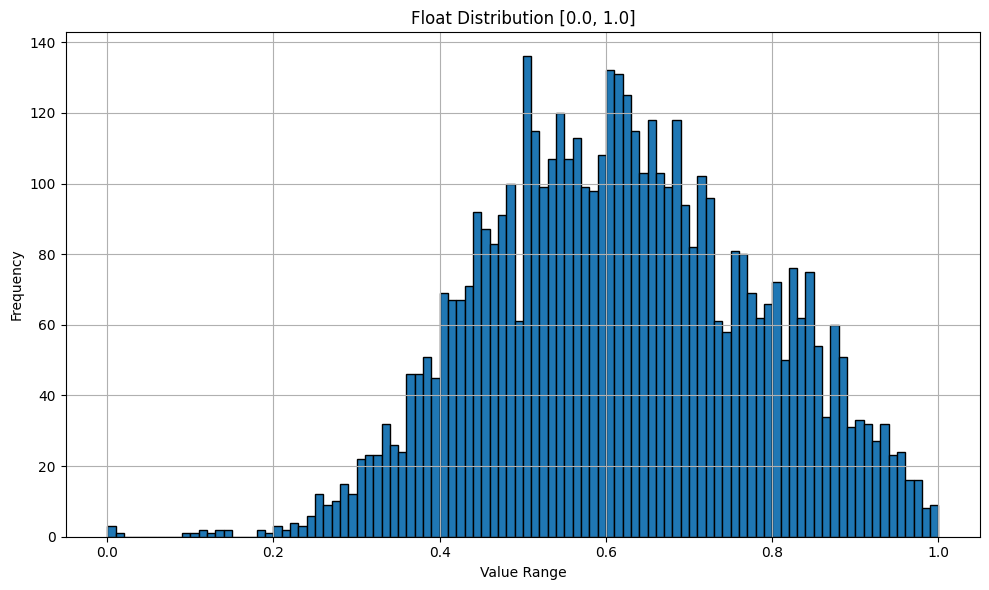

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

file_path = "/home/jin467/github_download/hnswlib/hnswlib/catch.bin"

floats = []
with open(file_path, "r") as f:
    for line in f:
        try:
            value = float(line.strip())
            floats.append(value)
        except ValueError:
            continue 

print(f"读取到 {len(floats)} 个浮点数")
print(f"最小值: {min(floats):.6f}, 最大值: {max(floats):.6f}")

plt.figure(figsize=(10, 6))
plt.hist(floats, bins=100, range=(0.0, 1.0), edgecolor='black')
plt.title("Float Distribution [0.0, 1.0]")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()
